<h1>K Nearest Neighbours</h1>

Classification algorithm based on the fundamental idea that data points with similar attributes tend to fall in to similar categories. For a dataset of points, where the class of each point is known, a new unclassified point can be classified by comparing it to it's nearest neighbours.

Recap:

 - Feature: Information asociated with a datapoint. 

 For this notebook, an example scenario of classifying breast tumours as canerous of benign. <bf>Malignant ->0 , benign -> 1</bf>.

In [1]:
from sklearn.datasets import load_breast_cancer
breast_cancer_data = load_breast_cancer()

<h2>Initial inspection of the data</h2>

As this is an exercise demonstrating understanding of KNN, exploratory data analysis is not included, nor is cleaning and data wrangling. The dataset is ready to use.

In [2]:
print("First data point in the dataset")
print(breast_cancer_data.data[0]) # First point of the data set

# Features of the dataset
print("Features of the dataset:")
print(breast_cancer_data.feature_names)

First data point in the dataset
[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
Features of the dataset:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


Printing the target variable to inform classification

In [3]:
print(f"Breast cancer target {breast_cancer_data.target}")
print(f"Breast cancer classifier{breast_cancer_data.target_names}")

Breast cancer target [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1

<h2>Splitting the data</h2>

In [4]:
from sklearn.model_selection import train_test_split

training_data, validation_data, training_labels, validation_labels = train_test_split(breast_cancer_data.data, breast_cancer_data.target, test_size=0.2, random_state=100)

len(training_data) == len(training_labels)

True

In [5]:
len(validation_data) == len(validation_labels)

True

<h2> Building the model from scratch</h2>

The formula for the the distance between two points can be generalised. Dimensions large enough high encounter an issue wrt the curse of dimensionlity. Using the generalised formula the distances can be used to find the nearest neighbours to each point. 

In [6]:
def distance(point1, point2):
    """
    Parameters: point1, point2 - list of features representing a data point. For example, [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]

    Returns Distance between each feature of these points
    """
    point1_len = len(point1)
    point2_len = len(point1)
    # Check len match otherwise raise exception
    if point1_len != point2_len:
        raise Exception("Movie feature dimensions not equal")
    
    # Calculate distance:
    total_feature_distance = 0
    for i in range(point1_len):
        feature_distance = (point1[i] - point2[i]) ** 2
        total_feature_distance += feature_distance
        distance = total_feature_distance ** 0.5
    return distance

<h2>Normalisation</h2>

Data of features likely will not follow the same scale, in which case normalisation methods are employed. Consider example features of budget and release date - these are on vastly different scales in our case nearly zero weight will be given to the release dates since they are so small compared to the budgets. This is because the distance formula accounts for each feature equally.

In [7]:
def min_max_normalise(lst):
    """
    Parameters: lst - list of parameters to be normalised
    """
    minimum = min(lst)
    maximum = max(lst)
    normalised = []
    for i in range(len(lst)):
        normalised_i = lst[i] - minimum / minimum + maximum 
        normalised.append(normalised_i)
    return normalised

The next step after normalising the data is to find the nearest neighbours. In this case I want to find the K nearest neighbours, examine their classification and use this information to inform the classification of the unknown point. 

To start, k=5 with the expectation this value will be refined to find more accurate results. 

In [8]:
def classify(unknown, dataset, labels, k):
  distances = []
  #Looping through all points in the dataset
  for pt_index, data in enumerate(dataset):
    distance_to_point = distance(data, unknown)
    distances.append([distance_to_point, pt_index])
    #Adding the distance and point associated with that distance
    distances.append([distance_to_point, pt_index])
  distances.sort()
  #Taking only the k closest points
  neighbors = distances[0:k]
  num_malignant = 0
  num_benign = 0 
  for neighbor in neighbors:
    patient_data = neighbor[1]
    classification = labels[patient_data]
    if classification == 1:
     num_benign  += 1
    else:
      num_malignant += 1
  if num_benign > num_malignant:
    return 1
  else:
    return 0

<h2>Training and Validation Sets</h2>

In [9]:
guess = classify(validation_data[0], training_data, training_labels, 5)
print(guess)

if guess == validation_labels[0]:
  print("Correct!")
else:
  print("Wrong!")

0
Correct!


<h2>Choosing K</h2>
By testing every point in the training set a score of the accuracy can be determined. Validation accuracy changes as k changes.

Small K will result in the model overfitting - this is a result of relying too heavily on the training data. Assuming it represents the population data entirely. A single outlier could incorrectly change the classification.

Large K makes the model prone to underfitting because the model looses understanding of the training data. 

In [10]:
print(validation_data)
print(validation_labels)

[[1.791e+01 2.102e+01 1.244e+02 ... 1.964e-01 3.245e-01 1.198e-01]
 [1.434e+01 1.347e+01 9.251e+01 ... 1.087e-01 3.062e-01 6.072e-02]
 [2.016e+01 1.966e+01 1.311e+02 ... 1.425e-01 3.055e-01 5.933e-02]
 ...
 [1.303e+01 1.842e+01 8.261e+01 ... 5.013e-02 1.987e-01 6.169e-02]
 [1.825e+01 1.998e+01 1.196e+02 ... 1.932e-01 3.063e-01 8.368e-02]
 [9.847e+00 1.568e+01 6.300e+01 ... 6.528e-02 2.502e-01 9.209e-02]]
[0 1 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1
 1 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 1 0 0
 1 1 1 0 0 1 1 0 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 1 0
 1 0 1]


In [11]:
def find_validation_accuracy(training_set, training_labels, validation_set, validation_labels, k):
    num_correct = 0
    for idx, pt_data in enumerate(validation_set):
        guess = classify(pt_data, training_set, training_labels, k)
        # Determine actual classification label 
        actual_label = validation_labels[idx]
        if guess == actual_label:
            num_correct += 1
        else:
            num_correct += 0
    validation_error = num_correct/len(validation_set)
    return validation_error

In [12]:
find_validation_accuracy(training_data, training_labels, validation_data, validation_labels, 5)

0.9473684210526315

<h2>Using sklearn </h2>

(0.9649122807017544, 56)


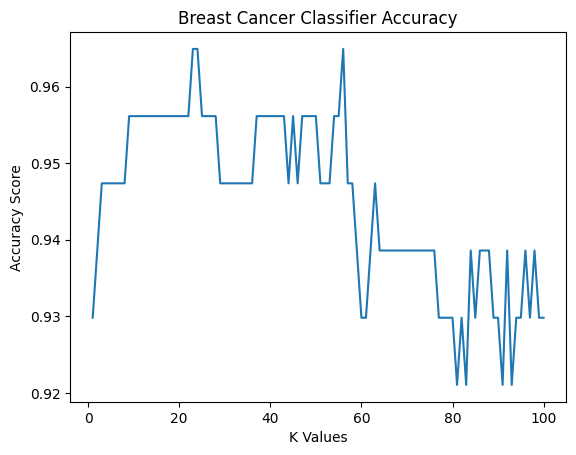

In [19]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors = 3)
# Train the model 
classifier.fit(training_data, training_labels)
# Score the model
score = classifier.score(validation_data, validation_labels)

scores = []
for k_value in range(1,101):
  classifier = KNeighborsClassifier(n_neighbors = k_value)
  classifier.fit(training_data, training_labels)
  score = classifier.score(validation_data, validation_labels)
  scores.append((score, k_value))
  max_score = max(scores)
print(max_score)

# Plot the accuracy as k changes
import matplotlib.pyplot as plt
accuracies = [accuracy[0] for accuracy in scores]
k_list = range(1,101)
plt.plot(k_list, accuracies)
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")
plt.title("Breast Cancer Classifier Accuracy")
plt.show()

Use a k-value of 16 for most accurate results.